In [198]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Наложение и удаление шума

In [199]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

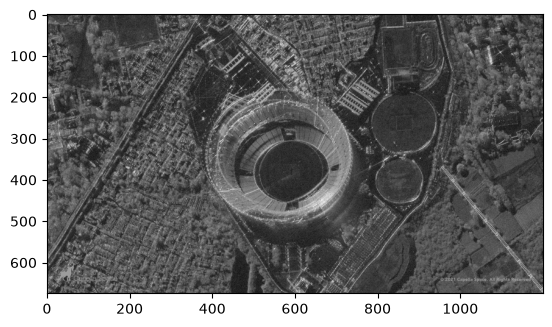

In [200]:
plt.imshow(image_gray, cmap="gray")

In [201]:
# Gaussian noise
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[ 36,   0,   0, ...,   1,   0,  83],
       [ 39,   0,  94, ...,  27,  72,   9],
       [  0,   0,   0, ...,  73,   0,  58],
       ...,
       [  0,  63, 123, ...,  62, 108,  14],
       [  0,  32,   0, ...,  98,   0,   0],
       [ 79,  27,   0, ...,  85,  25,  69]],
      shape=(675, 1200), dtype=uint8)

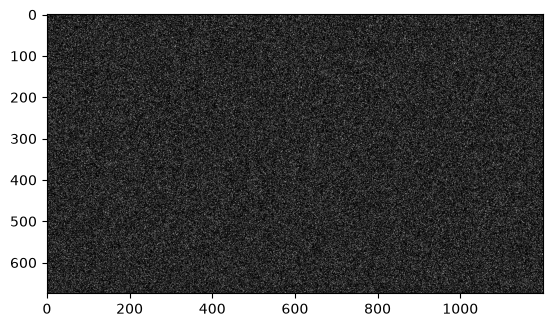

In [202]:
plt.imshow(noise_gauss, cmap="gray")

In [203]:
# Salt and pepper
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

In [204]:
bg_image = np.ones(image_gray.shape, np.uint8) * 128

In [205]:
bg_image[zeros_pixel] = 0
bg_image[ones_pixel] = 255

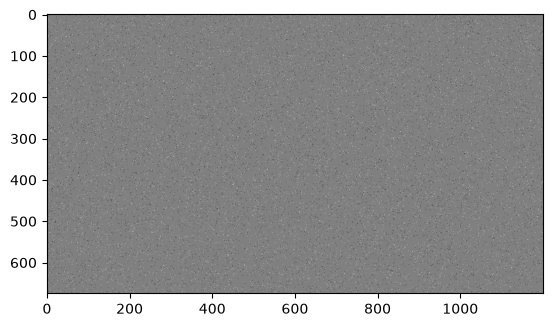

In [206]:
plt.imshow(bg_image, cmap="gray")

In [207]:
image_noise_gauss = cv2.add(image_gray,noise_gauss)

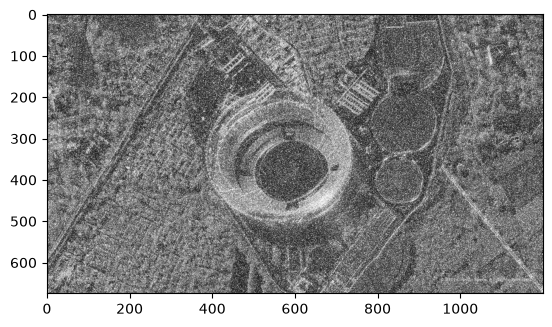

In [208]:
plt.imshow(image_noise_gauss, cmap="gray")

In [209]:
from skimage.metrics import structural_similarity, mean_squared_error
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim)

4226.888581481481 0.18699574640925934


In [210]:
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)

In [211]:
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray,  image_gauss_median, full=True)

In [212]:
print(mse_gauss_median, ssim_gauss_median)

1030.3099901234568 0.429603525217266


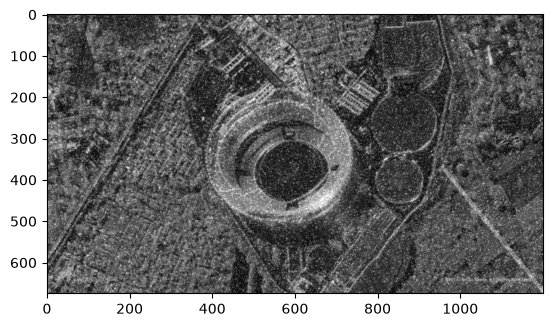

In [213]:
plt.imshow(image_gauss_median, cmap="gray")

In [214]:
import copy

image_sp = copy.deepcopy(image_gray)

image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

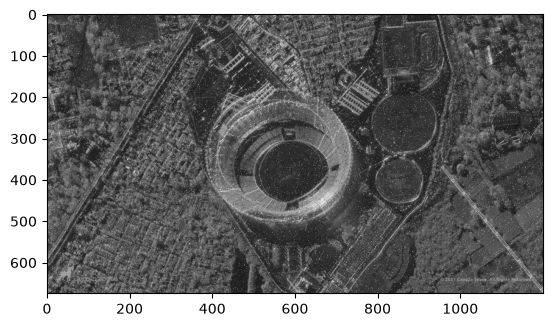

In [215]:
plt.imshow(image_sp, cmap="gray")

In [216]:
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

394.3409012345679 0.7170528530519519


In [217]:
image_sp_median = cv2.medianBlur(image_sp, 3)

In [218]:
mse_sp_median = mean_squared_error(image_gray, image_sp_median)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median, full=True)
print(mse_sp_median, ssim_sp_median)

95.74484320987655 0.8160813895280961


# Другие типы фильтров

In [219]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5),0)

In [220]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)

In [221]:
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)

In [222]:
import math

def geom(a):
    prod = 1
    for i in range(a.shape[0]):
        prod1 = 1
        for j in range(a.shape[1]):
            prod1 *= a[i,j]
        prod1 = math.pow(prod1, 1.0/9.0)
        prod *= prod1
    return prod

def proc(img, filter):
    img_res = copy.deepcopy(img)
    for i in range(0,img.shape[0] -2):
        for j in range(0,img.shape[1] -2):
            img_res[i:i+3, j:j+3] = filter(img[i:i+3, j:j+3])
    return img_res
    
res = proc(image_noise_gauss, geom)


C:\Users\L3and1r\AppData\Local\Temp\ipykernel_1752\164976186.py:8: RuntimeWarning: overflow encountered in scalar multiply
  prod1 *= a[i,j]


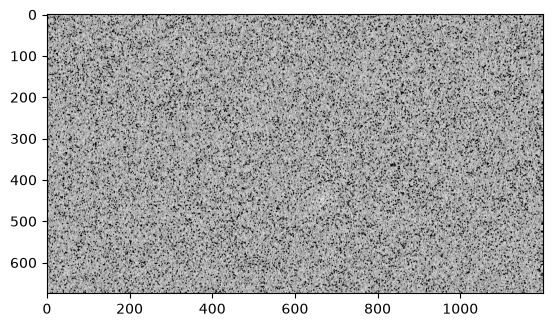

In [223]:
plt.imshow(res, cmap="gray")

In [224]:
mse_geom = mean_squared_error(image_gray, res)
(ssim_geom, diff) = structural_similarity(image_gray, res, full=True)
print(mse_geom, ssim_geom)

6551.063625925926 0.02748132365432562



# 2D свертка

In [225]:
# averaging filter
kernel_5 = np.ones((5,5),np.float32)/25
image_k5 = cv2.filter2D(image_gray,-1,kernel_5)
# blured_image = cv2.blur(img,(5,5))
image_b5 = cv2.blur(image_gray,(5,5))

In [226]:
mse_kb = mean_squared_error(image_k5, image_b5)
(ssim_kb, diff) = structural_similarity(image_k5, image_b5, full=True)
print(mse_kb, ssim_kb)

0.0 1.0


In [227]:
# Laplasian
kernel_lapl = np.array([[0,-10,0],
                        [-10,40,-10],
                        [0,-10,0]], np.float32)

In [228]:
image_lapl = cv2.filter2D(image_gray,-1,kernel_lapl) 

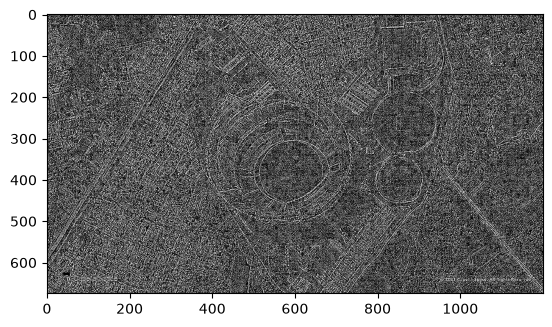

In [229]:
plt.imshow(image_lapl, cmap="gray")

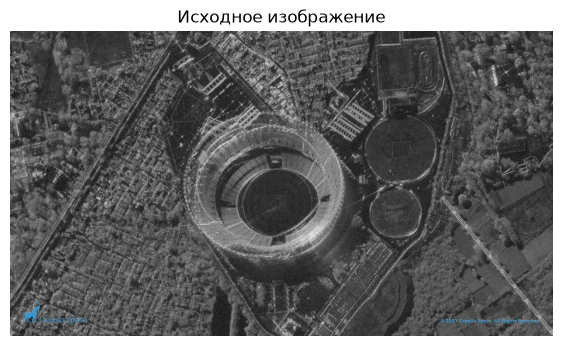

In [230]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data

np.random.seed(42)

image_rgb = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(7, 5))
plt.imshow(image_rgb)
plt.title('Исходное изображение')
plt.axis('off')
plt.show()

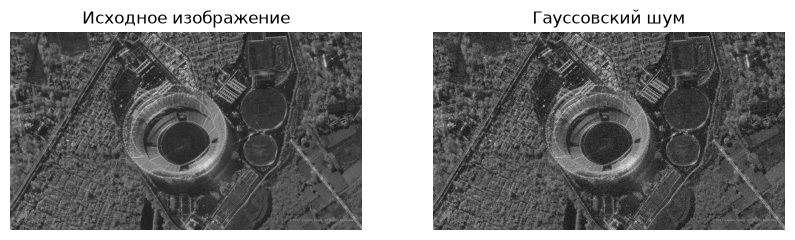

In [231]:
mean = 0
sigma = 20

gaussian_noise = np.random.normal(mean, sigma, image_gray.shape)
gaussian_image = image_gray.astype(np.float32) + gaussian_noise
gaussian_image = np.clip(gaussian_image, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')
plt.show()

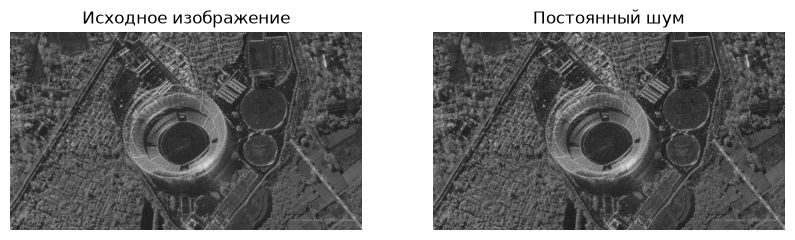

In [232]:
min_noise = -20
max_noise = 20

uniform_noise = np.random.uniform(min_noise, max_noise, image_gray.shape)
uniform_image = image_gray.astype(np.float32) + uniform_noise
uniform_image = np.clip(uniform_image, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(uniform_image, cmap='gray')
plt.title('Постоянный шум')
plt.axis('off')
plt.show()

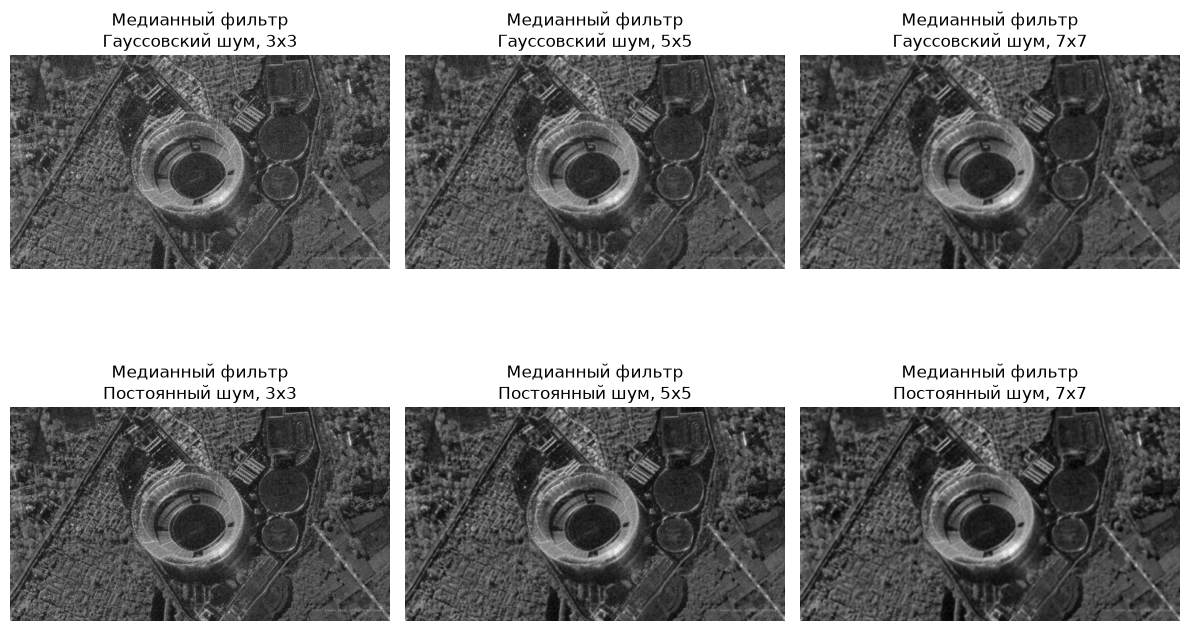

In [233]:
# Медианный фильтр

median_3 = cv2.medianBlur(gaussian_image, 3)
median_5 = cv2.medianBlur(gaussian_image, 5)
median_7 = cv2.medianBlur(gaussian_image, 7)

uniform_median_3 = cv2.medianBlur(uniform_image, 3)
uniform_median_5 = cv2.medianBlur(uniform_image, 5)
uniform_median_7 = cv2.medianBlur(uniform_image, 7)

plt.figure(figsize=(12, 8))
for i, (img, title) in enumerate([
    (median_3, 'Гауссовский шум, 3x3'),
    (median_5, 'Гауссовский шум, 5x5'),
    (median_7, 'Гауссовский шум, 7x7'),
    (uniform_median_3, 'Постоянный шум, 3x3'),
    (uniform_median_5, 'Постоянный шум, 5x5'),
    (uniform_median_7, 'Постоянный шум, 7x7')
], 1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap='gray')
    plt.title('Медианный фильтр\n' + title)
    plt.axis('off')
plt.tight_layout()
plt.show()

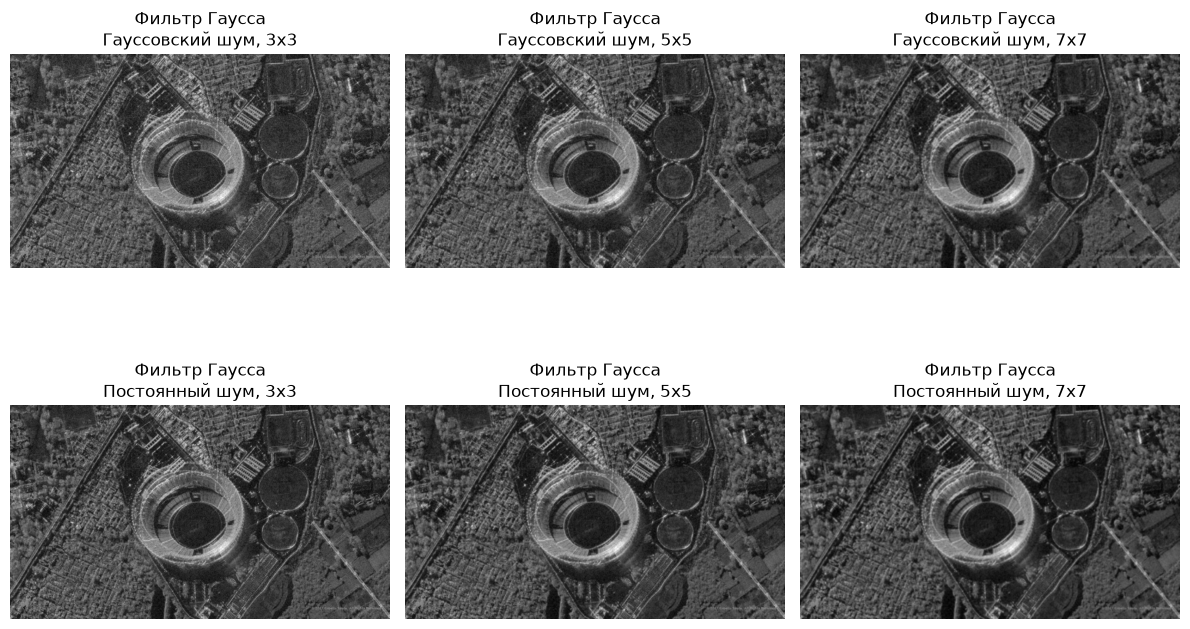

In [234]:
# Фильтр Гаусса

gauss_3 = cv2.GaussianBlur(gaussian_image, (3, 3), 0)
gauss_5 = cv2.GaussianBlur(gaussian_image, (5, 5), 0)
gauss_7 = cv2.GaussianBlur(gaussian_image, (7, 7), 0)

uniform_gauss_3 = cv2.GaussianBlur(uniform_image, (3, 3), 0)
uniform_gauss_5 = cv2.GaussianBlur(uniform_image, (5, 5), 0)
uniform_gauss_7 = cv2.GaussianBlur(uniform_image, (7, 7), 0)

plt.figure(figsize=(12, 8))
for i, (img, title) in enumerate([
    (gauss_3, 'Гауссовский шум, 3x3'),
    (gauss_5, 'Гауссовский шум, 5x5'),
    (gauss_7, 'Гауссовский шум, 7x7'),
    (uniform_gauss_3, 'Постоянный шум, 3x3'),
    (uniform_gauss_5, 'Постоянный шум, 5x5'),
    (uniform_gauss_7, 'Постоянный шум, 7x7')
], 1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap='gray')
    plt.title('Фильтр Гаусса\n' + title)
    plt.axis('off')
plt.tight_layout()
plt.show()

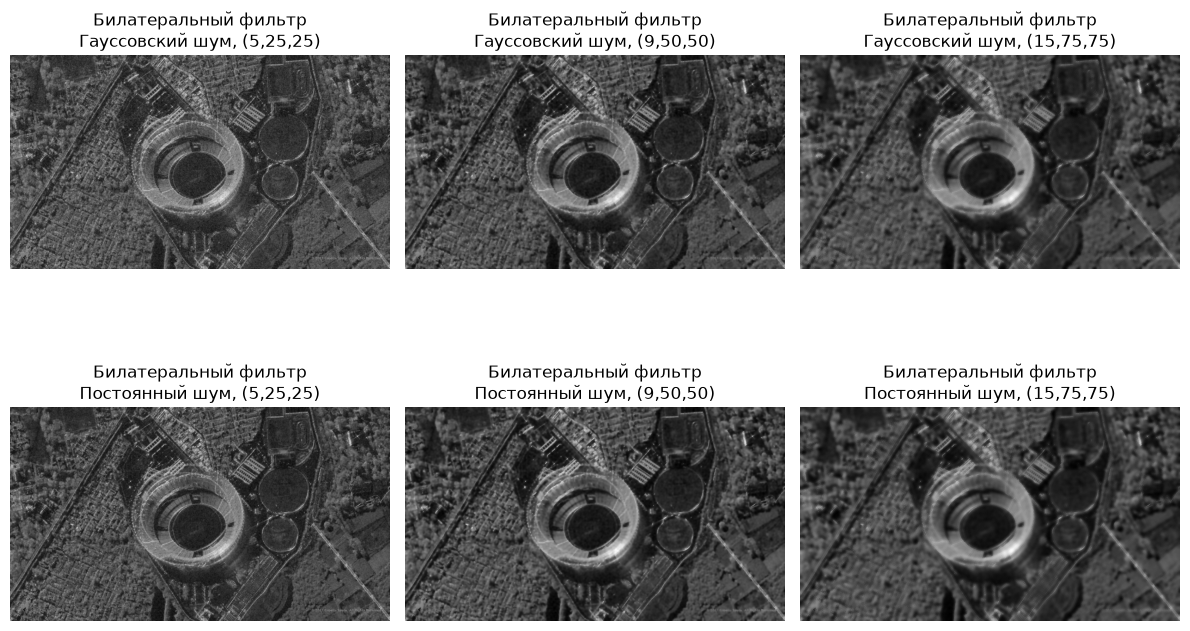

In [235]:
# Билатеральный фильтр

bilateral_1 = cv2.bilateralFilter(gaussian_image, 5, 25, 25)
bilateral_2 = cv2.bilateralFilter(gaussian_image, 9, 50, 50)
bilateral_3 = cv2.bilateralFilter(gaussian_image, 15, 75, 75)

uniform_bilateral_1 = cv2.bilateralFilter(uniform_image, 5, 25, 25)
uniform_bilateral_2 = cv2.bilateralFilter(uniform_image, 9, 50, 50)
uniform_bilateral_3 = cv2.bilateralFilter(uniform_image, 15, 75, 75)

plt.figure(figsize=(12, 8))
for i, (img, title) in enumerate([
    (bilateral_1, 'Гауссовский шум, (5,25,25)'),
    (bilateral_2, 'Гауссовский шум, (9,50,50)'),
    (bilateral_3, 'Гауссовский шум, (15,75,75)'),
    (uniform_bilateral_1, 'Постоянный шум, (5,25,25)'),
    (uniform_bilateral_2, 'Постоянный шум, (9,50,50)'),
    (uniform_bilateral_3, 'Постоянный шум, (15,75,75)')
], 1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap='gray')
    plt.title('Билатеральный фильтр\n' + title)
    plt.axis('off')
plt.tight_layout()
plt.show()

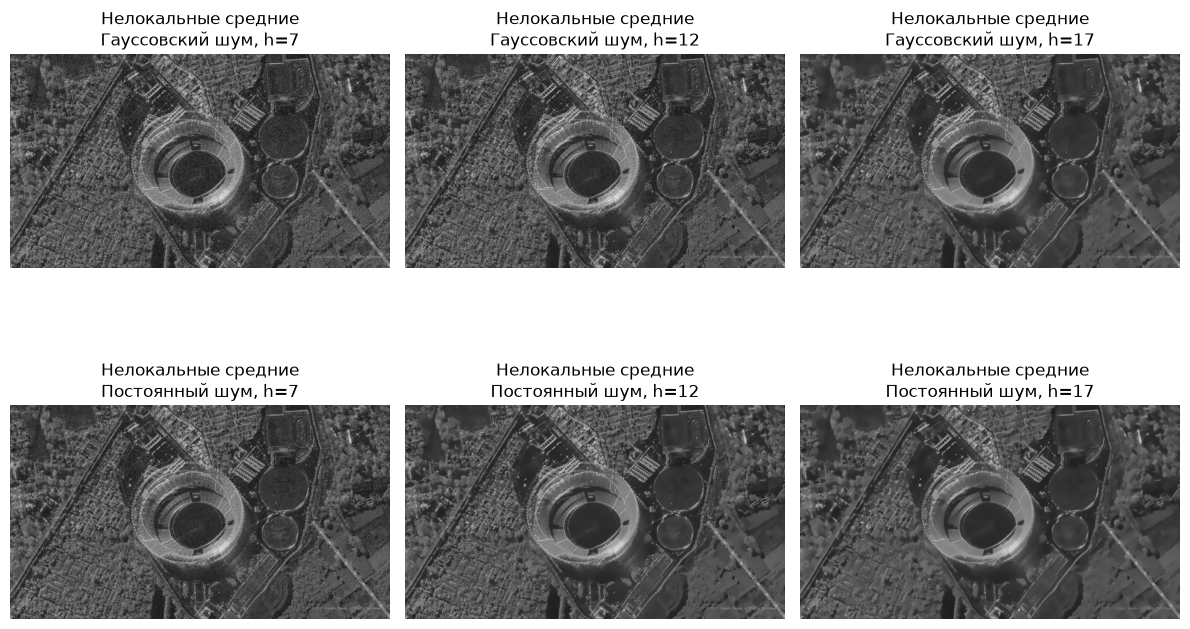

In [236]:


nlm_1 = cv2.fastNlMeansDenoising(gaussian_image, None, 7, 7, 21)
nlm_2 = cv2.fastNlMeansDenoising(gaussian_image, None, 12, 7, 21)
nlm_3 = cv2.fastNlMeansDenoising(gaussian_image, None, 17, 7, 21)

uniform_nlm_1 = cv2.fastNlMeansDenoising(uniform_image, None, 7, 7, 21)
uniform_nlm_2 = cv2.fastNlMeansDenoising(uniform_image, None, 12, 7, 21)
uniform_nlm_3 = cv2.fastNlMeansDenoising(uniform_image, None, 17, 7, 21)

plt.figure(figsize=(12, 8))
for i, (img, title) in enumerate([
    (nlm_1, 'Гауссовский шум, h=7'),
    (nlm_2, 'Гауссовский шум, h=12'),
    (nlm_3, 'Гауссовский шум, h=17'),
    (uniform_nlm_1, 'Постоянный шум, h=7'),
    (uniform_nlm_2, 'Постоянный шум, h=12'),
    (uniform_nlm_3, 'Постоянный шум, h=17')
], 1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap='gray')
    plt.title('Нелокальные средние\n' + title)
    plt.axis('off')
plt.tight_layout()
plt.show()

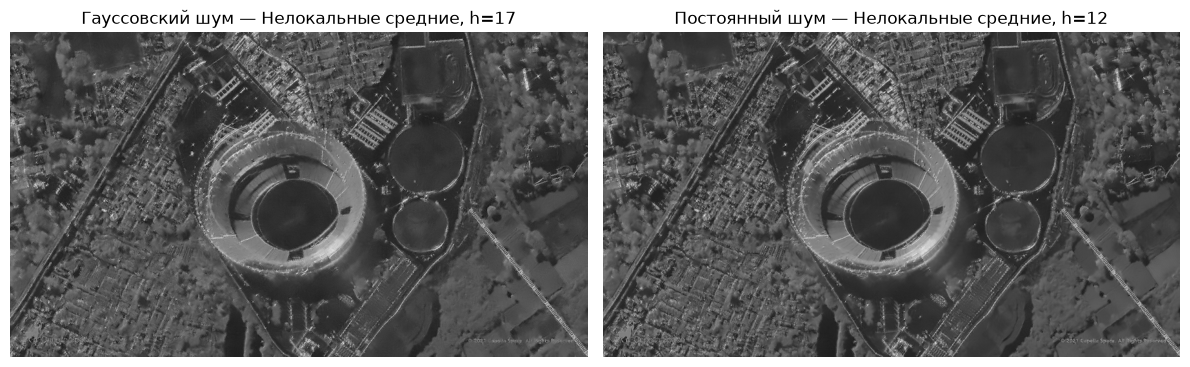

In [237]:
# Сравнение результатов

best_gaussian = nlm_3
best_uniform = uniform_nlm_2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(best_gaussian, cmap='gray')
plt.title('Гауссовский шум — Нелокальные средние, h=17')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(best_uniform, cmap='gray')
plt.title('Постоянный шум — Нелокальные средние, h=12')
plt.axis('off')

plt.tight_layout()
plt.show()


### Вывод

В работе изображение было зашумлено гауссовским и постоянным шумом. Для каждого шума были протестированы медианный фильтр, фильтр Гаусса, билатеральный фильтр и фильтр нелокальных средних с различными параметрами. По результатам сравнения наиболее удачным оказался фильтр нелокальных средних: для гауссовского шума — при h=17, для постоянного шума — при h=12.